In [191]:
import numpy as np

def DTWDistance(s, t, w):
    n, m = len(s), len(t)
    w = max(w, abs(n - m))  # Ensure the window is at least large enough to cover the difference in lengths
    
    # Create the DTW matrix initialized with infinity
    DTW = np.full((n + 1, m + 1), np.inf)
    DTW[0, 0] = 0
    
    # Initialize the boundary conditions in the DTW matrix
    for i in range(1, n + 1):
        start = max(1, i - w)
        end = min(m, i + w) + 1
        DTW[i, start:end] = 0

    # Vectorized calculation of DTW values
    for i in range(1, n + 1):
        j_start = max(1, i - w)
        j_end = min(m, i + w) + 1
        j_range = np.arange(j_start, j_end)
        
        # Compute the cost matrix for this slice
        cost = np.abs(s[i-1] - t[j_range - 1])
        
        # Calculate minimum costs for each cell in the current slice
        DTW[i, j_range] = cost + np.minimum(DTW[i - 1, j_range],    # insertion
                                            np.minimum(DTW[i, j_range - 1],  # deletion
                                                       DTW[i - 1, j_range - 1]))  # match

    return DTW[n, m]




In [232]:
import numpy as np
import matplotlib.pyplot as plt 


def find_alignment_path(DTW):
    i, j = DTW.shape[0] - 2, DTW.shape[1] - 2
    path = []

    while i > 0 and j > 0:
        path.append((i, j))
        # Get the costs of the three possible previous steps
        cost_diagonal = DTW[i-1, j-1]
        cost_up = DTW[i-1, j]
        cost_left = DTW[i, j-1]

        # Choose the predecessor with the minimum cost
        if cost_diagonal <= cost_up and cost_diagonal <= cost_left:
            i, j = i - 1, j - 1
        elif cost_up <= cost_left:
            i -= 1
        else:
            j -= 1

    # Handle the boundary of the matrix
    while i > 0:
        path.append((i, 0))
        i -= 1
    while j > 0:
        path.append((0, j))
        j -= 1

    path.append((0, 0))  # Add the start point
    path.reverse()  # Reverse the path to start from the beginning
    path = np.array(path, dtype=int)
    return path.T



def DTWDistance(s, t):
    n, m = len(s), len(t)
    # Create the DTW matrix initialized with infinity
    DTW = np.full((n + 1, m + 1), np.inf)
    DTW[0, 0] = 0  # Starting point

    # Fill the DTW matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s[i - 1] - t[j - 1])**2# + (i - j)**2/((n*m)) # Cost calculation
            # Compute the minimum of insertion, deletion, and match
            DTW[i, j] = cost + min(DTW[i - 1, j],    # insertion
                                   DTW[i, j - 1],    # deletion
                                   DTW[i - 1, j - 1])  # match

    alignment_path = find_alignment_path(DTW)  # Find the alignment path
    return DTW[n, m], alignment_path  # Return the distance



In [233]:
# def DTWDistance(s, t, w=100):
#     n, m = len(s), len(t)
#     DTW = np.full((n + 1, m + 1), np.inf)

#     w = max(w, abs(n - m))  # adapt window size

#     for i in range(n + 1):
#         for j in range(m + 1):
#             DTW[i, j] = np.inf

#     DTW[0, 0] = 0

#     for i in range(1, n + 1):
#         for j in range(max(1, i - w), min(m, i + w) + 1):
#             DTW[i, j] = 0

#     for i in range(1, n + 1):
#         for j in range(max(1, i - w), min(m, i + w) + 1):
#             cost = abs(s[i - 1] - t[j - 1])
#             DTW[i, j] = cost + min(DTW[i - 1, j], DTW[i, j - 1], DTW[i - 1, j - 1])

#     alignment_path = find_alignment_path(DTW)  # Find the alignment path
#     return DTW[n, m], alignment_path  # Return the distance and the alignment path


In [235]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


3.598667734438738


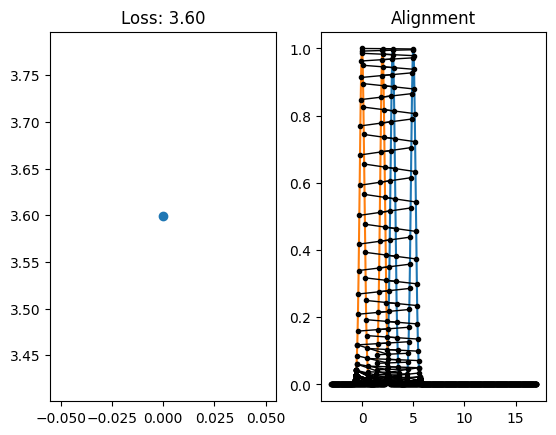

In [6]:
# Example usage
fig, ax = plt.subplots(1,2)
t = np.linspace(-3, 17, 600)

def spike_fn(t, loc1, loc2):
    return np.exp(-(t - loc1)**2*10) + np.exp(-(t - loc2)**2*10)

target = spike_fn(t, 3, 5)

locations1 = np.linspace(0, 10, 20)
locations2 = np.linspace(2, 16, 20)
loss, alignment = DTWDistance(target, spike_fn(t, locations1[0], locations2[0]))
ax[0].plot(0, loss, 'o')
ax[0].set_title(f"Loss: {loss:.2f}")
ax[1].cla()
ax[1].plot(t, target)
ax[1].plot(t, spike_fn(t, locations1[0], locations2[0]))
ax[1].plot([t[alignment[0]], t[alignment[1]]], [target[alignment[0]], spike_fn(t, locations1[0], locations2[0])[alignment[1]]], '.-', color="black", linewidth=1)
ax[1].set_title("Alignment")

print(loss)

def update(frame):
    loss, alignment = DTWDistance(target, spike_fn(t, locations1[frame], locations2[frame]))
    ax[0].plot(frame, loss, 'o', color="C0")
    ax[0].set_title(f"Loss: {loss:.2f}")
    ax[1].cla()
    ax[1].plot(t, target)
    ax[1].plot(t, spike_fn(t, locations1[frame], locations2[frame]))
    ax[1].plot([t[alignment[0]], t[alignment[1]]], [target[alignment[0]], spike_fn(t, locations1[frame], locations2[frame])[alignment[1]]], '.-', color="black", linewidth=1)
    ax[1].set_title("Alignment")
    return ax

ani = FuncAnimation(fig, update, frames=range(1,20), blit=False)
plt.show()

In [7]:
from IPython.display import HTML
HTML(ani.to_jshtml())

In [236]:
import jax 
import jax.numpy as jnp

In [319]:

def find_alignment_path(DTW):
    i, j = DTW.shape[0] - 2, DTW.shape[1] - 2
    path = []

    while i > 0 and j > 0:
        path.append((i, j))
        # Get the costs of the three possible previous steps
        cost_diagonal = DTW[i-1, j-1]
        cost_up = DTW[i-1, j]
        cost_left = DTW[i, j-1]

        # Choose the predecessor with the minimum cost
        if cost_diagonal <= cost_up and cost_diagonal <= cost_left:
            i, j = i - 1, j - 1
        elif cost_up <= cost_left:
            i -= 1
        else:
            j -= 1

    # Handle the boundary of the matrix
    while i > 0:
        path.append((i, 0))
        i -= 1
    while j > 0:
        path.append((0, j))
        j -= 1

    path.append((0, 0))  # Add the start point
    path.reverse()  # Reverse the path to start from the beginning
    path = np.array(path, dtype=int)
    return path.T

In [321]:
def naive_dtw_distance(x, y, return_alignment=False):
    n, m = len(x), len(y)
    idx = jnp.arange(1, m + 1)
    # Create the DTW matrix initialized with infinity
    DTW = jnp.full((n + 1, m + 1), np.inf)
    DTW = DTW.at[0, 0].set(0)  # Starting point
    
    def scan_col(carry,j):
        DTW,i = carry
        cost = abs(x[i - 1] - y[j - 1])**2
        DTW = DTW.at[i, j].set(cost + jnp.minimum(DTW[i - 1, j],    # insertion
                                   jnp.minimum(DTW[i, j - 1],    # deletion
                                   DTW[i - 1, j - 1]))) # match
        return (DTW,i), None
    
    def scan_row(carry,i):
        final_carry, _ = jax.lax.scan(scan_col, carry + (i,), idx, unroll=4)
        return (final_carry[0],), None
        
    final_carry,_ = jax.lax.scan(scan_row,(DTW,), jnp.arange(1, n + 1), unroll=4)
    DTW = final_carry[0]
    
    if return_alignment:
        alignment = find_alignment_path(DTW)  # Find the alignment path
        return DTW[n, m], alignment
    else:
        return DTW[n, m]

In [553]:

from functools import partial


def pad_inf(inp, before, after):
    return jnp.pad(inp, (before, after), constant_values=jnp.inf)

@partial(jax.jit, static_argnums=(2,))
def _dtw_distance(x,y, cost_fn= lambda x,y: (x-y)**2):
    
    D = jax.vmap(jax.vmap(cost_fn, in_axes=(0, None)), in_axes=(None, 0))(x, y)
    
    H, W = D.shape

    rows = []
    for row in range(D.shape[0]):
        rows.append( pad_inf(D[row], row, D.shape[0]-row-1) )
    model_matrix = jnp.stack(rows, axis=1)
    
    init = (
            pad_inf(model_matrix[0], 1, 0),
            pad_inf(model_matrix[1] + model_matrix[0, 0], 1, 0)
    )

    def scan_step(carry, current_antidiagonal):
        two_ago, one_ago = carry

        diagonal = two_ago[:-1]
        right    = one_ago[:-1]
        down     = one_ago[1:]
        best     = jnp.min(jnp.stack([diagonal, right, down], axis=-1), axis=-1)

        next_row = best + current_antidiagonal
        next_row = pad_inf(next_row, 1, 0)

        return (one_ago, next_row), next_row

    # Manual unrolling:
    # carry = init
    # for i, row in enumerate(model_matrix[2:]):
    #     carry, y = scan_step(carry, row)

    carry, ys = jax.lax.scan(scan_step, init, model_matrix[2:], unroll=4)
    return carry[1][-1]


In [790]:
@jax.jit
def kth_cost_diag(x,y, k):
    n, m = len(x), len(y)
    start_row, start_col = (0,k)

    # Create arrays of row and column indices
    rows = jnp.arange(n-1, -1, -1)
    cols = jnp.arange(m-1, -1, -1)
    rows = rows + start_row
    cols = cols + start_col
    rows = jnp.where(rows < 0, n , rows)
    cols = jnp.where(cols < 0, m , cols)
    
    x_k = jnp.take(x, rows, fill_value=jnp.inf)
    y_k = jnp.take(y, cols, fill_value=jnp.inf)
    c_k = jnp.abs(x_k - y_k)**2
    
    return c_k


@partial(jax.jit, static_argnums=(2,))
def _mem_eff_dtw_distance(x,y, cost_fn= lambda x,y: (x-y)**2):
    
    H, W = x.shape[0], y.shape[0]
    x= x[::-1] # Wrote code to get diagonal, but want antidiagonals...

    two_ago = kth_cost_diag(x,y, -H + 1)
    one_ago = kth_cost_diag(x,y, -H + 2) + two_ago[0]
    
    init = (
            pad_inf(two_ago, 1, 0),
            pad_inf(one_ago, 1, 0)
    )

    def scan_step(carry, k):
        two_ago, one_ago = carry
        current_antidiagonal = kth_cost_diag(x,y, k)

        diagonal = two_ago[:-1]
        right    = one_ago[:-1]
        down     = one_ago[1:]
        best     = jnp.min(jnp.stack([diagonal, right, down], axis=-1), axis=-1)

        next_row = best + current_antidiagonal
        next_row = pad_inf(next_row, 1, 0)

        return (one_ago, next_row), None

    ks = jnp.arange(-H + 3,H)

    carry, ys = jax.lax.scan(scan_step, init, ks, unroll=4)
    return carry[1][-1]

In [799]:
ks = jnp.arange(-H + 1, H)
model_matrix = jax.vmap(kth_cost_diag, in_axes=(None, None, 0))(x[::-1], y, ks)

In [800]:
D = jnp.abs(x[:, None] - y[None, :])**2
rows = []
for row in range(D.shape[0]):
    rows.append( pad_inf(D[row], row, D.shape[0]-row-1) )
model_matrix2 = jnp.stack(rows, axis=1)

In [802]:
model_matrix2[2:]

Array([[6132.8716, 6571.364 , 7009.864 , ...,       inf,       inf,
              inf],
       [5633.719 , 6050.719 , 6468.65  , ...,       inf,       inf,
              inf],
       [5159.5864, 5554.991 , 5952.1733, ...,       inf,       inf,
              inf],
       ...,
       [      inf,       inf,       inf, ..., 3877.4878, 4154.711 ,
        4431.9663],
       [      inf,       inf,       inf, ...,       inf, 4280.985 ,
        4576.688 ],
       [      inf,       inf,       inf, ...,       inf,       inf,
        4709.173 ]], dtype=float32)

In [753]:
x = jnp.cos(jnp.linspace(-3, 17, 600))*100
y = jnp.sin(jnp.linspace(-3, 17, 600))*100

In [793]:

jax.jit(_mem_eff_dtw_distance)(x ,x)

Array(0., dtype=float32)

In [795]:

_dtw_distance(x,x)

Array(0., dtype=float32)

In [759]:
#%%timeit
jax.jit(naive_dtw_distance)(x,y)

Array(90948.41, dtype=float32, weak_type=True)

In [760]:
DTWDistance(x,y)

KeyboardInterrupt: 

In [186]:
def softmin_impl(x, gamma=1., axis=-1):
    return -gamma * jax.scipy.special.logsumexp(x / -gamma, axis=axis)

    
softmin = jax.custom_vjp(softmin_impl)

def softmin_fwd(array, gamma=1., axis=-1):
    return softmin(array, gamma=gamma, axis=axis), (array / -gamma, )

def softmin_bwd(res, g):
    scaled_array, = res
    grad = jnp.where(jnp.isinf(scaled_array),
        jnp.zeros(scaled_array.shape),
        jax.nn.softmax(scaled_array) * jnp.expand_dims(g, 1)
    )
    return grad,

softmin.defvjp(softmin_fwd, softmin_bwd)
''

def pad_inf(inp, before, after):
    return jnp.pad(inp, (before, after), constant_values=jnp.inf)

In [187]:
softmin(jnp.array([1,2,3, 4, 5, 0.5]), gamma=0.1)

Array(0.49932843, dtype=float32)

In [722]:
x = jnp.cos(jnp.linspace(0, 2*jnp.pi, 100))
y = jnp.cos(jnp.linspace(1, 2*jnp.pi, 100))

In [663]:
D = jnp.abs(x[:, None] - y[None, :])
rows = []
for row in range(D.shape[0]):
    rows.append( pad_inf(D[row], row, D.shape[0]-row-1) )
model_matrix = jnp.stack(rows, axis=1)

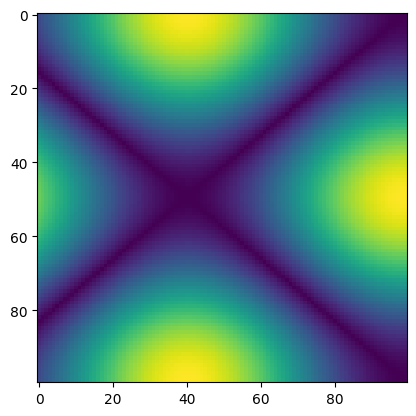

In [664]:
plt.imshow(D)

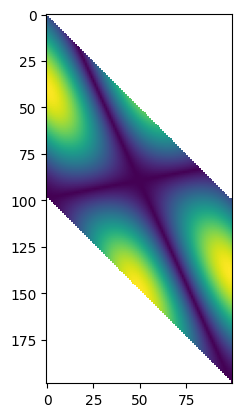

In [665]:
plt.imshow(model_matrix)

In [666]:
model_matrix[0]

Array([0.45969772,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        

In [453]:
from functools import partial



def kth_diag_indices(n, m, k=0):

    start_row, start_col = jax.lax.cond(k >= 0, lambda _: (0, k), lambda _: (-k, 0), None)

    # Determine the maximum possible length of the diagonal
    length = jnp.minimum(n - start_row, m - start_col)

    # Create arrays of row and column indices
    rows = jnp.arange(start_row, start_row + length)
    cols = jnp.arange(start_col, start_col + length)

    return rows, cols

def compute_kth_diag(x,y,k: int):
    rows, cols = kth_diag_indices(x.shape[0], y.shape[0], k)
    print(rows, cols)
    D = jnp.abs(x[rows] - y[cols])
    return D    
    

In [305]:
idx1, idx2 = kth_diag_indices(x.shape[0], y.shape[0], -x.shape[0] + 3)

In [304]:
jnp.abs((x[idx1] - y[idx2]))

Array([0.45165253, 0.50333774, 0.55241275], dtype=float32)

In [306]:
model_matrix[2]

Array([0.55241275, 0.50333774, 0.45165253,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        

In [96]:
def DTWDistance(s, t):
    n, m = len(s), len(t)
    # Create the DTW matrix initialized with infinity
    DTW = np.full((n + 1, m + 1), np.inf)
    DTW[0, 0] = 0  # Starting point

    # Fill the DTW matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s[i - 1] - t[j - 1])**2
            # Compute the minimum of insertion, deletion, and match
            DTW[i, j] = cost + min(DTW[i - 1, j],    # insertion
                                   DTW[i, j - 1],    # deletion
                                   DTW[i - 1, j - 1])  # match

    alignment_path = find_alignment_path(DTW)  # Find the alignment path
    return DTW[n, m], alignment_path  # Return the distance



In [97]:
import numpy as np

def dtw_distance_vectorized(seqA, seqB):
    N, M = len(seqA), len(seqB)
    previous_row = np.full(M + 1, np.inf)
    current_row = np.full(M + 1, np.inf)
    
    previous_row[0] = 0  # Initialize the starting point

    for i in range(1, N + 1):
        current_row[0] = np.inf  # Edge of the matrix, cannot match to nothing
        for j in range(1, M + 1):
            cost = (seqA[i-1] - seqB[j-1]) ** 2
            # Compute the minimum cost considering the three possible scenarios
            current_row[j] = cost + min(previous_row[j],     # insertion
                                        current_row[j-1],    # deletion
                                        previous_row[j-1])   # match
        # Update previous_row to be the current_row before the next iteration
        previous_row[:] = current_row

    return previous_row[M]  # The bottom right cell of the matrix is the DTW distance


def compute_kth_diag(x,y,k: int):
    rows, cols = kth_diag_indices(x.shape[0], y.shape[0], k)
    D = jnp.abs(x[rows] - y[cols])
    return D    

In [98]:
dtw_distance_vectorized(x,y)

0.0

In [99]:
%%timeit
DTWDistance(x,y)[0]

KeyboardInterrupt: 

In [546]:
%%timeit
_dtw_distance(x,y)

1.98 ms ± 866 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [538]:
from functools import partial

In [59]:
D = jnp.abs(x[:, None] - y[None, :])
H, W = D.shape
rows = []
for row in range(H):
    rows.append( pad_inf(D[row], row, H-row-1) )

model_matrix = jnp.stack(rows, axis=1)

In [81]:
def kth_diag_indices(n, m, k=0):
    # Calculate starting row and column based on k
    if k >= 0:
        start_row = 0
        start_col = k
    else:
        start_row = -k
        start_col = 0

    # Determine the maximum possible length of the diagonal
    length = min(n - start_row, m - start_col)

    # Create arrays of row and column indices
    rows = jnp.arange(start_row, start_row + length)
    cols = jnp.arange(start_col, start_col + length)

    return rows, cols

In [82]:
idx1, idx2 = kth_diag_indices(*model_matrix.shape, x.shape[0]- 100)

In [276]:
idx1

Array([0, 1, 2], dtype=int32)

In [277]:
idx2

Array([97, 98, 99], dtype=int32)

In [61]:
def compute_kth_diag(x,y,k):
    rows, cols = kth_diag_indices(x.shape[0], y.shape[0], k)
    print(rows.shape, cols.shape)
    D = jnp.abs(x[rows] - y[cols])
    return D    

In [89]:
compute_kth_diag(x,y,-(x.shape[0] - 100))

(100,) (100,)


Array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.20389539e-45, 3.08285662e-44, 2.52233724e-43, 2.01786979e-42,
       1.57940350e-41, 1.20946070e-40, 9.05704039e-40, 6.63284309e-39,
       4.75039507e-38, 3.32718164e-37, 2.27897748e-36, 1.52658260e-35,
       1.00004000e-34, 6.40665268e-34, 4.01385587e-33, 2.45928626e-32,
       1.47357821e-31, 8.63483544e-31, 4.94825043e-30, 2.77310319e-29,
       1.51983762e-28, 8.14601248e-28, 4.26982174e-27, 2.18872493e-26,
       1.09720901e-25, 5.37903396e-25, 2.57890897e-24, 1.20916197e-23,
       5.54433785e-23, 2.48617504e-22, 1.09026090e-21, 4.67569253e-21,
      

In [91]:
model_matrix[-1]

Array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, in

In [273]:
@partial(jax.jit, static_argnums=(2,))
def _dtw_distance(x,y, cost_fn= lambda x,y: (x-y)**2):
    
    D = jax.vmap(jax.vmap(cost_fn, in_axes=(0, None)), in_axes=(None, 0))(x, y)
    
    H, W = D.shape

    two_ago = jnp.concatenate([D[0], jnp.full(H-1, jnp.inf)])
    one_ago = jnp.concatenate([D[1], jnp.full(H-1, jnp.inf)])
    one_ago = one_ago.at[0].set(D[0, 0])

    init = (
        pad_inf(two_ago, 1, 0),
        pad_inf(one_ago, 1, 0)
    )

    def scan_step(carry, i):
        two_ago, one_ago = carry

        current_antidiagonal = jnp.full(2*H-1, jnp.inf)
        current_antidiagonal = jax.lax.dynamic_update_slice(current_antidiagonal, D[i], one_ago)
        
        
        diagonal = two_ago[:-1]
        right    = one_ago[:-1]
        down     = one_ago[1:]
        best     = jnp.min(jnp.stack([diagonal, right, down], axis=-1),axis=-1)

        next_row = best + current_antidiagonal
        next_row = pad_inf(next_row, 1, 0)

        return (one_ago, next_row), next_row



    carry, ys = jax.lax.scan(scan_step, init, jnp.arange(2, 2*H-1), unroll=4)
    return carry[1][-1]


In [533]:
def _dtw_distance_memory_efficient(x,y, cost_fn = lambda x,y: (x-y)**2) -> float:
    
    x = jnp.array(x)
    y = jnp.array(y)
    n, m = x.shape[0], y.shape[0] # n >= m !
    
    vmap_costn_fn = jax.vmap(cost_fn, in_axes=(None, 0))
    
    def scan_step(carry, i):
        previous_row, current_row = carry
        current_row = current_row.at[0].set(0)
        cost = vmap_costn_fn(x[i-1], y)
        current_row_update = jnp.minimum(current_row[1:], jnp.minimum(previous_row[1:], previous_row[:-1])) + cost
        current_row = current_row.at[1:].set(current_row_update)
        return (current_row, current_row), None
    

    previous_row = jnp.full(m+1, jnp.inf)
    previous_row = previous_row.at[0].set(0)
    current_row = jnp.full(m+1, jnp.inf)
    
    final_carry, _ = jax.lax.scan(scan_step, (previous_row, current_row), jnp.arange(1, n+1), unroll=4)
    
    return final_carry[1][-1]
    
    
    

In [498]:
_dtw_distance_memory_efficient(x,y)

Array(39.587666, dtype=float32, weak_type=True)

In [408]:
pad_inf(jnp.array([1,2,3,4.,5]),1,0)

Array([inf,  1.,  2.,  3.,  4.,  5.], dtype=float32)

In [404]:
def scan_step(carry, current_antidiagonal):
    two_ago, one_ago = carry

    diagonal = two_ago[:-1]
    right    = one_ago[:-1]
    down     = one_ago[1:]
    best     = self.minimum(jnp.stack([diagonal, right, down], axis=-1))

    next_row = best + current_antidiagonal
    next_row = pad_inf(next_row, 1, 0)

    return (one_ago, next_row), next_row

In [732]:
def soft_threshold(x, eta=10, threshold=-20):
    return jax.nn.sigmoid(eta * (x - threshold))

def weight_fn(x, p=0.9, q = 0.9):
    return jnp.where(x > 0, q**x, p**(-x))

def spike_prob(x, eta=10, threshold=-20, p=0.8, q=0.8, k=50):
    window = weight_fn(jnp.arange(-k,k), p, q)
    window = window / jnp.sum(window)
    return jnp.convolve(g(x, eta, threshold) , window, mode = "same")



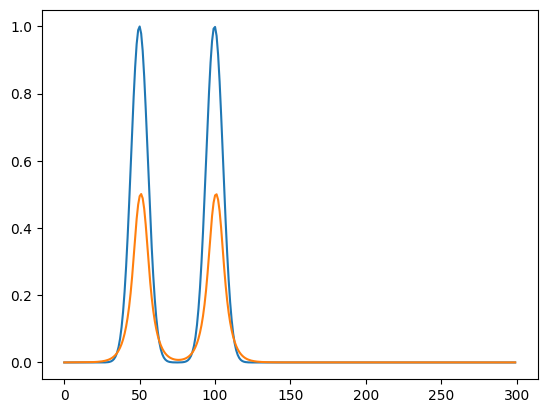

In [733]:
plt.plot(x)
plt.plot(spike_prob(x, threshold=0.8))

In [722]:
spike_prob(jnp.zeros(100), threshold=0.5, eta=10)

Array([0.0029746 , 0.00372692, 0.00432878, 0.00481027, 0.00519546,
       0.00550361, 0.00575013, 0.00594735, 0.00610512, 0.00623134,
       0.00633232, 0.0064131 , 0.00647772, 0.00652942, 0.00657078,
       0.00660387, 0.00663034, 0.00665152, 0.00666846, 0.00668201,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669285,
       0.00669285, 0.00669285, 0.00669285, 0.00669285, 0.00669